# Using MLP approach to create character level model

Inspiration: MLP based approach for a Word Level Model

1. Learning representation of token representation (here, characters; in research paper it was words)
2. Simulatenously, learning the model parameters

In [313]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt 

%matplotlib inline

In [314]:
data = open("../data.txt", 'r').read().splitlines()

In [315]:
stoi = {chr(97+i):i+1 for i in range(26)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}

In [316]:
# building dataset

context_size = 4    # context/block length
X, y = [], []

for w in data:

    context = [0] * context_size
    #print(w)
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        y.append(ix)
        #print(''.join(itos[i] for i in context), '--->', itos[ix])

        context = context[1:] + [ix]    # crop and append

X = torch.tensor(X)
y = torch.tensor(y)

In [317]:
# Lookup table for character representation by condensing them into lower dimension to prevent the dimension explosion problem
dimensions = 8

C = torch.randn((27, dimensions))    # 27 represents the vocabulary here 27 characters; 8 represents the number of dimensions we want to use to represent the characters
# in the RP: 17000 words were compressed into m dimensions, ie, (17000, m) lookup table

In [318]:
# embedding for the dataset

emb = C[X]
emb.shape

#emb.shape = (x, y, z) ---> x: no of rows of training set; y = size of context; z = dimensions

torch.Size([228146, 4, 8])

In [319]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility

# neural network
# number of input to the network = context_size * dimensions for each neuron

layer1size = 100

W1 = torch.randn(((context_size * dimensions), layer1size), generator=g)
b1 = torch.randn(layer1size, generator=g)

# to perform: emb @ W1 + b1
# therefore we need to change the shape of emb to (x, y*z)

# torch.concat(torch.unbind(emb, 1), 1)

emb = emb.view(emb.shape[0], context_size*dimensions)

# output layer parameters

W2 = torch.randn((layer1size, 27), generator=g)
b2 = torch.randn(27, generator=g)

parameters = [C, W1, b1, W2, b2]

In [320]:
h = torch.tanh(emb @ W1 + b1)   # first hidden layer
logits = h @ W2 + b2    # output layer

""" counts = logits.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[torch.arange(emb.shape[0]), y].log().mean()   # select the probability of the correct prediction(y) given by the current model
 """
loss = F.cross_entropy(logits, y)

In [321]:
for p in parameters:
    p.requires_grad = True

In [322]:
lr = 0.1

for _ in range(100):

    # mini batch
    randomindex = torch.randint(0, X.shape[0], (32,))   #32 here is batch size
    X_batch = X[randomindex]
    y_batch = y[randomindex]
    # forward pass
    emb = C[X_batch]
    h = torch.tanh(emb.view(emb.shape[0], context_size*dimensions) @ W1 + b1)   # first hidden layer
    logits = h @ W2 + b2    # output layer
    loss = F.cross_entropy(logits, y_batch)

    if(_ % 10 == 9):    print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    # update
    p.data += -lr * p.grad


18.20564842224121
21.372751235961914
14.694937705993652
18.250839233398438
16.572101593017578
16.87749481201172
16.908466339111328
20.7158145904541
17.383752822875977
18.02838706970215


## Using train, val, test split

In [323]:
nlen = X.shape[0]
ntest, nval = int(0.8*nlen), int(0.1*nlen)
X_train = X[:ntest]
y_train = y[:ntest]

X_val = X[ntest: ntest+nval]
y_val = y[ntest: ntest+nval]

X_test = X[ntest+nval:]
y_test = y[ntest+nval:]



In [324]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print(X_test.shape, y_test.shape)

torch.Size([182516, 4]) torch.Size([182516])
torch.Size([22814, 4]) torch.Size([22814])
torch.Size([22816, 4]) torch.Size([22816])


In [333]:
dimensions = 5
C = torch.randn((27, dimensions), generator=g)
emb = C[X_train]
emb = emb.view(emb.shape[0], context_size*dimensions)

In [334]:
layer1size = 200

W1 = torch.randn(((context_size * dimensions), layer1size))
b1 = torch.randn(layer1size)

W2 = torch.randn((layer1size, 27))
b2 = torch.randn(27)

parameters = [C, W1, b1, W2, b2]

In [335]:
for p in parameters:
    p.requires_grad = True

In [336]:
lr = 0.1

for _ in range(20000):

    # mini batch
    randomindex = torch.randint(0, X_train.shape[0], (32,))
    X_batch = X_train[randomindex]
    y_batch = y_train[randomindex]
    # forward pass
    emb = C[X_batch]
    h = torch.tanh(emb.view(emb.shape[0], context_size*dimensions) @ W1 + b1)   # first hidden layer
    logits = h @ W2 + b2    # output layer
    loss = F.cross_entropy(logits, y_batch)

    if(_ % 2000 == 0):    print(loss.item())

    #backward pass
    for p in parameters:
        p.grad = None

    loss.backward()

    # update
    lr = 0.1 if lr<10000 else 0.01
    p.data += -lr * p.grad

print(loss.item())

25.73884391784668
18.364608764648438
21.166250228881836
15.34941577911377
21.698637008666992
28.148710250854492
19.48696517944336
20.101213455200195
18.891765594482422
20.585437774658203
21.49186897277832


In [329]:
# using val datatset to test

emb = C[X_val]
h = torch.tanh(emb.view(-1, (context_size*dimensions)) @ W1 + b1)
logits = h @ W2 + b2
loss = F.cross_entropy(logits, y_val)

loss

tensor(25.7035, grad_fn=<NllLossBackward0>)

## Visualizing the embedding

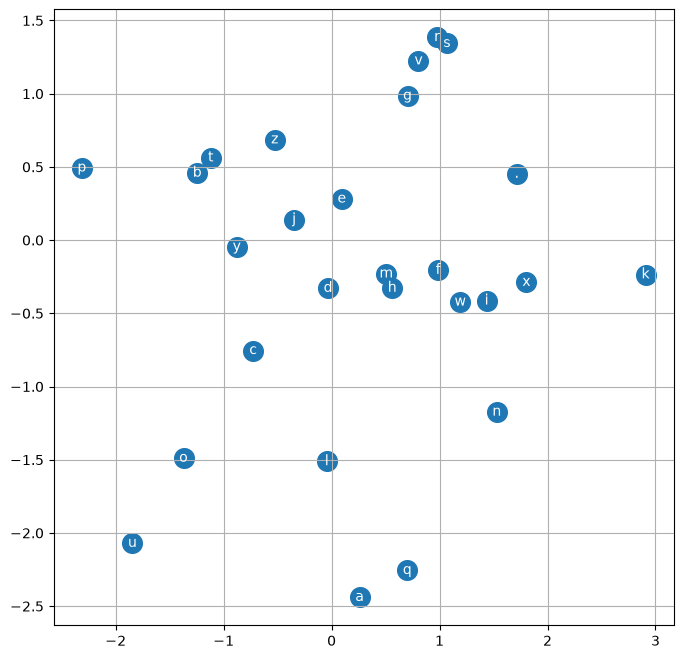

In [330]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters

plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [331]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * context_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

.
.
.
miahaaloiaarainailodltaajaljanearlinevayninlsutahaalaarainadearainaiatiadearlinevayninlxpatjaiatiadearainaiatiadearehrsniaedyunasnbceeeyysnareyiinehiysiiataadainodvainydmaahaaloiearuidearainadearehrsniaedeyzsaicbieeeyysnareyisnlkataadainodvaenadnydiy.
.
.
.
.
.
.
.
.
.
.
.
miavehnlnoyaxatkediynfmn.
.
.
.
.
